# Test Infomap
Here I'll try to implement a function to compute the Infomap description length, tested with the previously created Test networks!

Side note: [This](https://python.igraph.org/en/latest/tutorials/cluster_contraction.html) might be useful!


To Do:
- Teleportation probability
- Benchmarking
- Look into directed graphs?

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit

In [2]:
# little helper for plotting purposes
# might make a a seperate python file for all utility functions later on
def visual_community_colors(g: ig.Graph):
    if "community" in g.vertex_attributes():
        c = max(g.vs["community"]) + 1 
        palette = ig.RainbowPalette(n=c)
    visual_style = {}
    visual_style["vertex_size"] = 20
    visual_style["vertex_color"] = [palette.get(i) for i in g.vs["community"]] if "community" in g.vertex_attributes() else "lightblue"
    visual_style["layout"] = g.layout('fr')
    visual_style["bbox"] = (400, 400)
    visual_style["margin"] = 20
    visual_style["vertex_label_angle"] = 90
    visual_style["vertex_label_dist"] = 2.
    visual_style["edge_width"] = [1+w * 5 for w in g.es["weight"]] if "weight" in g.edge_attributes() else 1
    visual_style["edge_color"] = "rgba(1,1,1,0.7)" if "weight" in g.edge_attributes() else "rgba(1,1,1,1)"
    return visual_style

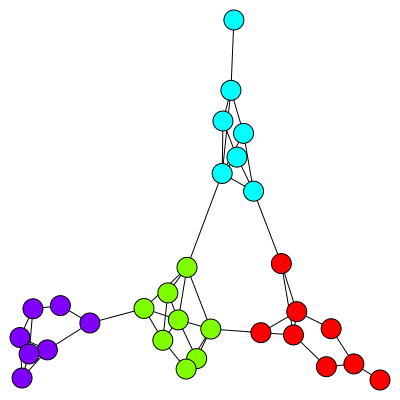

In [3]:
# load test networks
g1 = ig.Graph.Read_GraphML("test_graphs/unweighted_undirected.graphml")
ig.plot(g1, **visual_community_colors(g1))

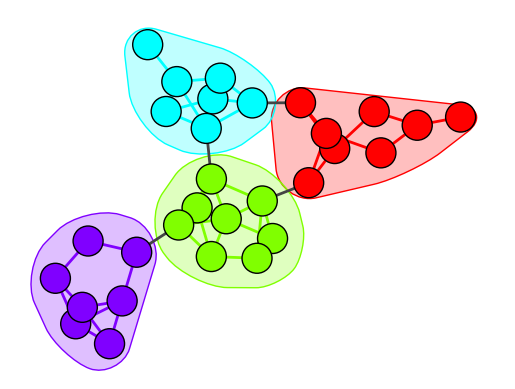

In [4]:
communities = ig.VertexClustering.FromAttribute(g1, "community")

num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g1.vs[community]["color"] = i   # Remove this to keep the original colors
    community_edges = g1.es.select(_within=community)
    community_edges["color"] = i

fig, ax = plt.subplots()
ig.plot(
    communities,
    target=ax,
    mark_groups=True,
    palette=palette
)
plt.show()

## Computing the description length
For the given test network with the given partitioning into communities, let's compute the description length as defined by the Map equation!
... which means we need the node visit frequencies etc. So, for our 4 cases:
- *unweighted, undirected*: node visit frequency = relative node degree? = degree(node)/2*|E| ??
- *weighted, undirected*: node visit frequency = relative weight of links connected to the node
$$ = \frac{w(\text{links connected to node})}{2\cdot w(\text{all links in network})}
$$
With directed networks, things get more complicated - need teleportation probability $\tau$, estimate ergodic node visit frequencies via power iteration method??
- *unweighted, directed*: TBA 
- *weighted, directed*: TBA

In [14]:
def compute_exit_weights(g: ig.Graph, membership: list[int]) -> np.ndarray:
    weights = np.array(g.es["weight"] if g.is_weighted() else [1.0] * g.ecount())
    membership = np.array(membership) # community membership list for each node
    exit_weights = np.zeros(max(membership) + 1) # initialise exit weight array

    edges = np.array(g.get_edgelist(), dtype=int) # array of edges
    src= membership[edges[:, 0]] # community of source node for each edge
    trg = membership[edges[:, 1]] # community of target node for each edge

    betw_communities = src != trg # true if edge connects different communities
    np.add.at(exit_weights, src[betw_communities], weights[betw_communities]) 
    np.add.at(exit_weights, trg[betw_communities], weights[betw_communities])

    return exit_weights

# custom log to avoid log(0) issues
def safe_log2(x):
    with np.errstate(divide='ignore'):
        return np.where(x > 0, np.log2(x), 0)

def compute_description_length(g: ig.Graph, communities: list[int]):
    # compute the description length of the given partitioning of the graph
    # so far, only works for undirected graphs
    if g.is_directed():
        raise NotImplementedError("Description length computation for directed graphs is not implemented yet.")
    
    weights = np.array(g.es["weight"] if g.is_weighted() else [1.0] * g.ecount())
    total_weight_x2 = 2 * np.sum(weights) # total weight of all edges (x2 for undirected graphs)
    # compute ergodic node visit frequencies
    p = np.array(g.strength(weights="weight" if g.is_weighted() else None)) / total_weight_x2
    p_mod = np.zeros(max(communities) + 1)
    np.add.at(p_mod, communities, p) # sum node visit frequencies for each community
    # compute module exit probabilities
    q = compute_exit_weights(g, communities) / total_weight_x2

    q_sum = np.sum(q) # total exit probability  

    # compute via map equation
    L = q_sum * safe_log2(q_sum) - 2* np.sum(q * safe_log2(q)) \
        - np.sum(p * safe_log2(p)) + np.sum((p_mod+q) * safe_log2(p_mod + q))
    return L 

In [15]:
communities = g1.community_infomap()
print(compute_description_length(g1, communities.membership))
print(communities.codelength)

3.4015829735877707
3.40158297358777


In [16]:
g2 = ig.Graph.Read_GraphML("test_graphs/weighted_undirected.graphml")
communities = g2.community_infomap()
print(compute_description_length(g2, list(map(int, communities.membership))))
print(communities.codelength)

3.4911212869303796
3.3818441007028666


Welp, this doesn't quite match.... According to Claude it's a matter of teleportation probability (which I sort of thought would only be considered in the case of directed graphs, but oh well - Future problem!)

## Finding partition with minimum description length
To be suitable for testing, let's remove the "ground truth" about community membership from the test network:

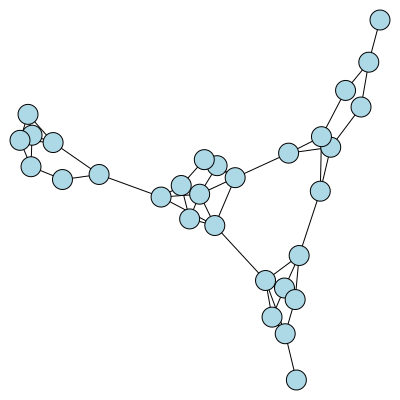

In [8]:
del g1.vs["community"] # remove community attribute for testing purposes    
ig.plot(g1, **visual_community_colors(g1))

In [9]:
%timeit -r50 communities = g1.community_infomap()

4.91 ms ± 267 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [10]:
# testing igraphs infomap implementation
communities = g1.community_infomap()
print(communities.codelength)

3.40158297358777


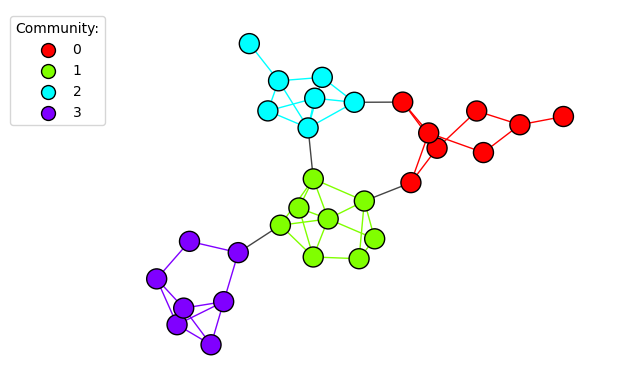

In [11]:
num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g1.vs[community]["color"] = i
    community_edges = g1.es.select(_within=community)
    community_edges["color"] = i

fig, ax = plt.subplots()
ig.plot(
    communities,
    palette=palette,
    edge_width=1,
    target=ax,
    vertex_size=20,
)

# Create a custom color legend
legend_handles = []
for i in range(num_communities):
    handle = ax.scatter(
        [],
        [],
        s=100,
        facecolor=palette.get(i),
        edgecolor="k",
        label=i,
    )
    legend_handles.append(handle)
ax.legend(
    handles=legend_handles,
    title="Community:",
    bbox_to_anchor=(0, 1.0),
    bbox_transform=ax.transAxes,
)
plt.show()